<a href="https://colab.research.google.com/github/hsiaoyouting/ResNet50_Wafer_Map_Recognition.ipynb/blob/main/wafer_defect_recognition_vit_pytorch_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Wafer Defect Recognition with PyTorch Vision Transformer

本 Notebook 將原本 TensorFlow/Keras 的 `wafer-defect-recognition-vit.ipynb`
改寫成可在 Google Colab 執行的 PyTorch 版本。

核心模型設定依照原 Notebook：
- Input: 52 × 52 × 1
- Patch size: 13 × 13
- Patches per image: 16
- Projection dimension: 96
- Attention heads: 4
- Transformer layers: 16
- Transformer MLP: 192 → 96
- Classification head: 2048 → 1024 → 8
- Multi-label classification: `BCEWithLogitsLoss`


## 1. Install / Import Libraries

In [1]:

!pip -q install kagglehub

import os
import glob
import time
import copy
import random
import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


In [2]:

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Using device: cpu


## 2. Download MixedWM38 Dataset

In [3]:

import kagglehub

dataset_root = kagglehub.dataset_download(
    "co1d7era/mixedtype-wafer-defect-datasets"
)
print("Dataset downloaded to:", dataset_root)

npz_candidates = glob.glob(
    os.path.join(dataset_root, "**", "Wafer_Map_Datasets.npz"),
    recursive=True
)

if not npz_candidates:
    raise FileNotFoundError(
        "Wafer_Map_Datasets.npz was not found under the downloaded dataset."
    )

dataset_path = npz_candidates[0]
print("Using:", dataset_path)


Using Colab cache for faster access to the 'mixedtype-wafer-defect-datasets' dataset.
Dataset downloaded to: /kaggle/input/mixedtype-wafer-defect-datasets
Using: /kaggle/input/mixedtype-wafer-defect-datasets/Wafer_Map_Datasets.npz


## 3. Data Loader

In [4]:

class WaferDataset(Dataset):
    def __init__(self, images, labels):
        self.images = np.asarray(images)
        self.labels = np.asarray(labels, dtype=np.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Original images are 52x52. Convert to float tensor and add channel:
        # (H, W) -> (1, H, W)
        image = torch.tensor(self.images[idx], dtype=torch.float32)
        if image.ndim == 2:
            image = image.unsqueeze(0)

        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return image, label


data = np.load(dataset_path)
images = data["arr_0"]
labels = data["arr_1"]

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Number of wafers:", len(images))


Images shape: (38015, 52, 52)
Labels shape: (38015, 8)
Number of wafers: 38015


In [5]:

# Same basic 80/20 split as the original TensorFlow notebook.
x_train, x_test, y_train, y_test = train_test_split(
    images,
    labels,
    test_size=0.2,
    random_state=SEED
)

train_dataset = WaferDataset(x_train, y_train)
test_dataset = WaferDataset(x_test, y_test)

BATCH_SIZE = 512
NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("Train:", len(train_dataset))
print("Test :", len(test_dataset))


Train: 30412
Test : 7603


## 4. Check Wafer Images

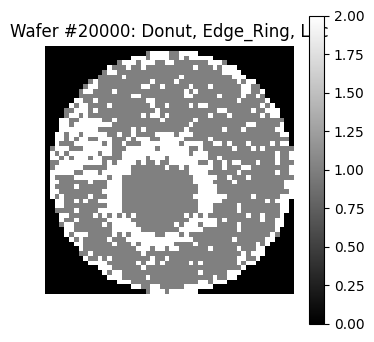

Label: [0 1 0 1 1 0 0 0]


In [6]:

label_keys = [
    "Center", "Donut", "Edge_Loc", "Edge_Ring",
    "Loc", "Near_Full", "Scratch", "Random"
]

def read_label(label):
    label = np.asarray(label)
    if label.sum() == 0:
        return "Normal wafer"
    return ", ".join(
        label_keys[i] for i, value in enumerate(label) if value == 1
    )

def show_wafer(index):
    plt.figure(figsize=(4, 4))
    plt.imshow(images[index], cmap="gray")
    plt.title(f"Wafer #{index}: {read_label(labels[index])}")
    plt.colorbar()
    plt.axis("off")
    plt.show()
    print("Label:", labels[index])

show_wafer(20000)


## 5. PyTorch Vision Transformer

In [7]:

class PatchEmbedding(nn.Module):
    def __init__(self, image_size=52, patch_size=13,
                 in_channels=1, projection_dim=96):
        super().__init__()

        assert image_size % patch_size == 0

        self.num_patches = (image_size // patch_size) ** 2
        patch_dim = in_channels * patch_size * patch_size

        # Equivalent to extracting non-overlapping patches and applying
        # a Dense(projection_dim) layer in the original Keras model.
        self.unfold = nn.Unfold(
            kernel_size=patch_size,
            stride=patch_size
        )
        self.projection = nn.Linear(patch_dim, projection_dim)
        self.position_embedding = nn.Parameter(
            torch.zeros(1, self.num_patches, projection_dim)
        )

        nn.init.trunc_normal_(self.position_embedding, std=0.02)

    def forward(self, x):
        # x: [B, 1, 52, 52]
        patches = self.unfold(x)               # [B, patch_dim, num_patches]
        patches = patches.transpose(1, 2)      # [B, num_patches, patch_dim]
        encoded = self.projection(patches)
        encoded = encoded + self.position_embedding
        return encoded


class WaferViT(nn.Module):
    def __init__(
        self,
        image_size=52,
        patch_size=13,
        in_channels=1,
        num_classes=8,
        projection_dim=96,
        num_heads=4,
        transformer_layers=16,
        transformer_mlp_dim=192,
        classifier_hidden=(2048, 1024),
        dropout=0.1,
        classifier_dropout=0.5
    ):
        super().__init__()

        self.patch_embedding = PatchEmbedding(
            image_size=image_size,
            patch_size=patch_size,
            in_channels=in_channels,
            projection_dim=projection_dim
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=projection_dim,
            nhead=num_heads,
            dim_feedforward=transformer_mlp_dim,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=False
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=transformer_layers
        )

        self.norm = nn.LayerNorm(projection_dim)

        num_patches = (image_size // patch_size) ** 2
        representation_dim = num_patches * projection_dim

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.2),
            nn.Linear(representation_dim, classifier_hidden[0]),
            nn.GELU(),
            nn.Dropout(classifier_dropout),
            nn.Linear(classifier_hidden[0], classifier_hidden[1]),
            nn.GELU(),
            nn.Dropout(classifier_dropout),
            nn.Linear(classifier_hidden[1], num_classes)
        )

    def forward(self, x):
        x = self.patch_embedding(x)
        x = self.transformer(x)
        x = self.norm(x)
        logits = self.classifier(x)
        return logits


model = WaferViT().to(device)
print(model)
print("Trainable parameters:",
      sum(p.numel() for p in model.parameters() if p.requires_grad))


WaferViT(
  (patch_embedding): PatchEmbedding(
    (unfold): Unfold(kernel_size=13, dilation=1, padding=0, stride=13)
    (projection): Linear(in_features=169, out_features=96, bias=True)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-15): 16 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=96, out_features=96, bias=True)
        )
        (linear1): Linear(in_features=96, out_features=192, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=192, out_features=96, bias=True)
        (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  (classifier): Sequential(
    (0): Fla

## 6. Check Patch Extraction

Image size: 52 X 52
Patch size: 13 X 13
Patches per image: 16
Elements per projected patch: 96


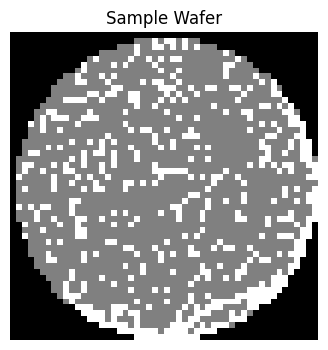

In [8]:

with torch.no_grad():
    sample_images, _ = next(iter(test_loader))
    sample_images = sample_images[:1].to(device)
    patch_tokens = model.patch_embedding(sample_images)

print("Image size: 52 X 52")
print("Patch size: 13 X 13")
print("Patches per image:", patch_tokens.shape[1])
print("Elements per projected patch:", patch_tokens.shape[2])

plt.figure(figsize=(4, 4))
plt.imshow(sample_images[0, 0].cpu().numpy(), cmap="gray")
plt.title("Sample Wafer")
plt.axis("off")
plt.show()


## 7. Training

In [ ]:

# Original notebook trained for 45 epochs.
EPOCHS = 45
LEARNING_RATE = 1e-3

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Mixed precision makes Colab GPU training faster and reduces memory use.
use_amp = torch.cuda.is_available()
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

best_val_loss = float("inf")
best_state = copy.deepcopy(model.state_dict())

history = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": []
}

def multilabel_accuracy(logits, labels, threshold=0.5):
    predictions = (torch.sigmoid(logits) >= threshold).float()
    return (predictions == labels).float().mean().item()

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    train_acc = 0.0
    train_count = 0

    progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for batch_images, batch_labels in progress:
        batch_images = batch_images.to(device, non_blocking=True)
        batch_labels = batch_labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=use_amp
        ):
            logits = model(batch_images)
            loss = criterion(logits, batch_labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        bs = batch_images.size(0)
        train_loss += loss.item() * bs
        train_acc += multilabel_accuracy(logits.detach(), batch_labels) * bs
        train_count += bs

        progress.set_postfix(loss=f"{loss.item():.4f}")

    train_loss /= train_count
    train_acc /= train_count

    # Validation
    model.eval()
    val_loss = 0.0
    val_acc = 0.0
    val_count = 0

    with torch.no_grad():
        for batch_images, batch_labels in test_loader:
            batch_images = batch_images.to(device, non_blocking=True)
            batch_labels = batch_labels.to(device, non_blocking=True)

            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16,
                enabled=use_amp
            ):
                logits = model(batch_images)
                loss = criterion(logits, batch_labels)

            bs = batch_images.size(0)
            val_loss += loss.item() * bs
            val_acc += multilabel_accuracy(logits, batch_labels) * bs
            val_count += bs

    val_loss /= val_count
    val_acc /= val_count

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_accuracy"].append(train_acc)
    history["val_accuracy"].append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )

# Restore best validation model
model.load_state_dict(best_state)
print("Best validation loss:", best_val_loss)


Epoch 1/45:   0%|          | 0/60 [00:00<?, ?it/s]

Epoch 01 | Train Loss: 0.5325 | Train Acc: 0.6982 | Val Loss: 0.5078 | Val Acc: 0.7122


Epoch 2/45:   0%|          | 0/60 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a65713702c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a65713702c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Epoch 02 | Train Loss: 0.5090 | Train Acc: 0.7075 | Val Loss: 0.5073 | Val Acc: 0.7122


...

Epoch 36/45:   0%|          | 0/60 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a65713702c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a65713702c0>

  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
Traceback (most recent call last):
      File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
if w.is_alive():    
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
self._shutdown_workers()
    assert self._parent_pid == os.getpid(), 'can only test a child process'  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    
if w.is_alive():AssertionError
:   File "/usr/lib/python3.13/multiprocessing/pro

Epoch 36 | Train Loss: 0.5069 | Train Acc: 0.7104 | Val Loss: 0.5069 | Val Acc: 0.7122


Epoch 37/45:   0%|          | 0/60 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a65713702c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a65713702c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

## 8. Plot Training History

In [ ]:

plt.figure(figsize=(8, 5))
plt.plot(history["train_accuracy"], label="Training accuracy")
plt.plot(history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Binary accuracy")
plt.legend()
plt.title("Training / Validation Accuracy")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Training loss")
plt.plot(history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training / Validation Loss")
plt.show()


## 9. Evaluate the Model

In [ ]:

model.eval()

all_probs = []
all_true = []

start_time = time.time()

with torch.no_grad():
    for batch_images, batch_labels in test_loader:
        batch_images = batch_images.to(device, non_blocking=True)

        logits = model(batch_images)
        probs = torch.sigmoid(logits).cpu().numpy()

        all_probs.append(probs)
        all_true.append(batch_labels.numpy())

elapsed = time.time() - start_time

all_probs = np.concatenate(all_probs, axis=0)
all_true = np.concatenate(all_true, axis=0)
all_pred = (all_probs >= 0.5).astype(np.float32)

print(f"Test prediction time: {elapsed:.2f} seconds")
print("Exact-match accuracy:",
      accuracy_score(all_true, all_pred))

print("\nClassification report:")
print(
    classification_report(
        all_true,
        all_pred,
        target_names=label_keys,
        zero_division=0
    )
)


## 10. Save the PyTorch Model

In [ ]:

save_path = "/content/wafer_vit_pytorch.pth"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "image_size": 52,
        "patch_size": 13,
        "projection_dim": 96,
        "num_heads": 4,
        "transformer_layers": 16,
        "num_classes": 8,
        "label_keys": label_keys,
        "history": history
    },
    save_path
)

print("Saved:", save_path)


## 11. Prediction Examples

In [ ]:

def predict_one(index):
    model.eval()

    image = torch.tensor(
        x_test[index],
        dtype=torch.float32
    ).unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(image)
        probs = torch.sigmoid(logits)[0].cpu().numpy()

    pred = (probs >= 0.5).astype(np.float32)

    plt.figure(figsize=(4, 4))
    plt.imshow(x_test[index], cmap="gray")
    plt.title(f"Test sample #{index}")
    plt.axis("off")
    plt.show()

    print("Ground-truth:", y_test[index])
    print("Probabilities:", np.round(probs, 3))
    print("Predictions   :", pred)
    print("Predicted defect type(s):", read_label(pred))

for idx in [900, 500, 3000]:
    if idx < len(x_test):
        predict_one(idx)



## 12. Notes for Colab Submission

1. Open this `.ipynb` in Google Colab.
2. Set **Runtime → Change runtime type → T4 GPU** (if available).
3. Run all cells from top to bottom.
4. When training and evaluation finish, save the notebook.
5. Take a screenshot showing the final evaluation result, especially:
   - Test prediction time
   - Exact-match accuracy
   - Classification report
6. Submit the screenshot according to the assignment's required upload/link format.

> The model is a PyTorch conversion of the supplied TensorFlow/Keras ViT notebook.
> The original model's patch size, projection dimension, attention heads, transformer depth,
> classifier dimensions, and 8-label output are retained.
